In [ ]:


import pandas as pd

# Read CSV file
employee_data = pd.read_csv('/content/employee1.csv')

print("\nOriginal Employee Data\n")
print(employee_data.head(10))

# Remove rows with missing values
employee_data = employee_data.dropna()

# Remove duplicate rows
employee_data = employee_data.drop_duplicates()

# Delete Bonus % column
employee_data = employee_data.drop('Bonus %', axis=1)

# Fix inconsistent team names
employee_data['Team'] = employee_data['Team'].replace({
    'Fin': 'Finance',
    'Mkt': 'Marketing',
    'Financeance': 'Finance'
})

print("\nCleaned Employee Data\n")
print(employee_data.head(10))

# Save cleaned data into a new CSV file
employee_data.to_csv('employees_cleaned.csv', index=False)

print("\nCSV file saved successfully!\n")

print("Name: Alisha Khatri ")
print("Roll no: 03 \n")


Original Employee Data

  FirstName  Gender  Salary  Bonus %       Team
0     Jerry    Male  138705    9.340        Fin
1    Louise  Female   63241   15.132        NaN
2   Douglas    Male   97308    6.945  Marketing
3   Douglas    Male   97308    6.945  Marketing
4   Matthew    Male  100612   13.645        Mkt
5     Scott     NaN  122367    5.218      Legal

Cleaned Employee Data

  FirstName Gender  Salary       Team
0     Jerry   Male  138705    Finance
2   Douglas   Male   97308  Marketing
4   Matthew   Male  100612  Marketing

CSV file saved successfully!

Name: Alisha Khatri 
Roll no: 03 



In [ ]:

import pandas as pd

# Read employee dataset
employee_data = pd.read_csv('employees.csv')

print("Original Employee Data")
print(employee_data.head(25))

# Fill missing salary values using mean
employee_data['Salary'] = employee_data['Salary'].fillna(
    employee_data['Salary'].mean()
)

print("\nData After Filling Missing Salary with Mean")
print(employee_data.head(25))

# Reload dataset for interpolation method
employee_data2 = pd.read_csv('employees.csv')

print("\nOriginal Data for Interpolation Method")
print(employee_data2.head(25))

# Fill missing salary values using linear interpolation
employee_data2['Salary'] = employee_data2['Salary'].interpolate(method='linear')

print("\nData After Linear Interpolation")
print(employee_data2.head(25))

# Save cleaned datasets
employee_data.to_csv('employees_mean_cleaned.csv', index=False)
employee_data2.to_csv('employees_interpolated.csv', index=False)

print("\nFiles Saved Successfully\n")

print("Name: Alisha Khatri ")
print("Roll no: 03 \n")

Original Employee Data
   First Name  Gender    Salary  Bonus %                  Team
0     Douglas    Male   97308.0    6.945             Marketing
1     Douglas    Male   97308.0    6.945             Marketing
2     Douglas    Male   97310.0    6.945             Marketing
3      Thomas    Male   61933.0    4.170                   NaN
4       Maria  Female  130590.0   11.858               Finance
5       Jerry    Male  138705.0    9.340                   Fin
6       Larry    Male       NaN    1.389       Client Services
7      Dennis    Male  115163.0   10.125                 Legal
8        Ruby  Female   65476.0   10.012               Product
9         NaN  Female   45906.0   11.598                   Fin
10     Angela  Female   95570.0   18.523           Engineering
11      Maria  Female  130590.0   11.858               Finance
12    Frances  Female  139852.0    7.524  Business Development
13     Louise  Female   63241.0   15.132                   NaN
14      Julie  Female  102508.0 

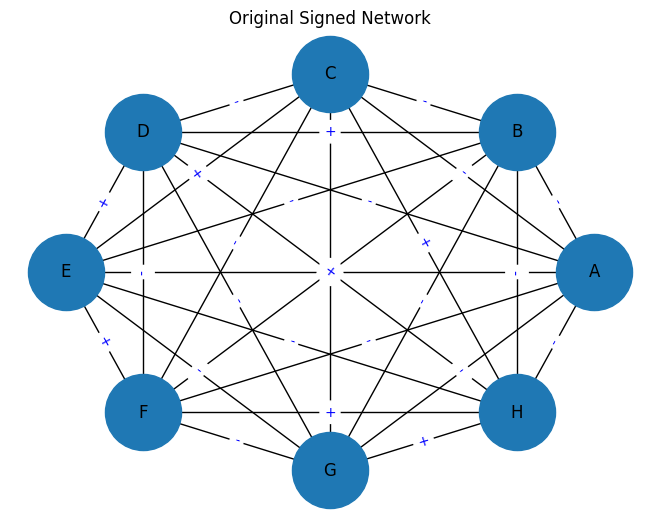

Initial Unstable Triangles: 36
Coalition 1: ['B', 'G', 'H']
Coalition 2: ['A', 'C', 'D', 'E', 'F']


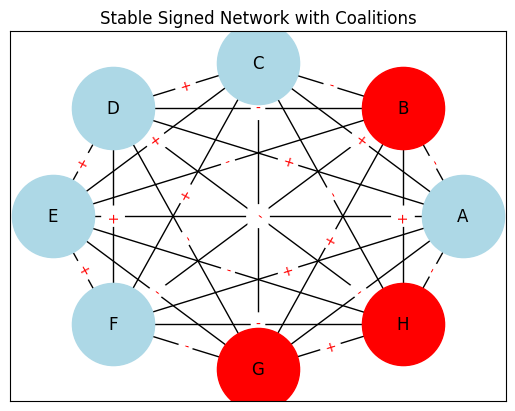

Name: Alisha Khatri 
Roll no: 03 



In [ ]:


import networkx as nx
import matplotlib.pyplot as plt
import random
import itertools

# Function to get signs of all triangles
def get_triangle_signs(graph, triangle_list):

    signs_data = []

    for triangle in triangle_list:
        temp = []

        temp.append(graph[triangle[0]][triangle[1]]['sign'])
        temp.append(graph[triangle[1]][triangle[2]]['sign'])
        temp.append(graph[triangle[2]][triangle[0]]['sign'])

        signs_data.append(temp)

    return signs_data


# Function to count unstable triangles
def count_unstable_triangles(signs_data):

    stable = 0

    for sign in signs_data:

        plus_count = sign.count('+')

        if plus_count == 1 or plus_count == 3:
            stable += 1

    unstable = len(signs_data) - stable

    return unstable


# Function to make graph stable
def stabilize_graph(graph, triangle_list, signs_data):

    unstable_found = False

    while not unstable_found:

        random_triangle = random.randint(0, len(triangle_list) - 1)

        if signs_data[random_triangle].count('+') % 2 == 0:
            unstable_found = True

    edge_choice = random.randint(1, 3)

    triangle = triangle_list[random_triangle]

    # Change sign of one edge
    if edge_choice == 1:

        current = graph[triangle[0]][triangle[1]]['sign']

        graph[triangle[0]][triangle[1]]['sign'] = '-' if current == '+' else '+'

    elif edge_choice == 2:

        current = graph[triangle[1]][triangle[2]]['sign']

        graph[triangle[1]][triangle[2]]['sign'] = '-' if current == '+' else '+'

    else:

        current = graph[triangle[0]][triangle[2]]['sign']

        graph[triangle[0]][triangle[2]]['sign'] = '-' if current == '+' else '+'

    return graph


# Function to form coalitions
def create_coalitions(graph):

    group1 = []
    group2 = []

    start_node = random.choice(list(graph.nodes()))

    group1.append(start_node)

    visited = []
    queue = [start_node]

    for node in queue:

        if node not in visited:

            neighbors = list(graph.neighbors(node))

            for neighbor in neighbors:

                if graph[node][neighbor]['sign'] == '+':

                    if neighbor not in group1:
                        group1.append(neighbor)

                    if neighbor not in queue:
                        queue.append(neighbor)

                else:

                    if neighbor not in group2:
                        group2.append(neighbor)

            visited.append(node)

    return group1, group2


# Create graph
graph = nx.Graph()

n = 8

graph.add_nodes_from(range(1, n + 1))

node_names = {
    1: "A", 2: "B", 3: "C", 4: "D",
    5: "E", 6: "F", 7: "G", 8: "H"
}

graph = nx.relabel_nodes(graph, node_names)

# Add edges with random signs
signs = ['+', '-']

for i in graph.nodes():
    for j in graph.nodes():

        if i != j:
            graph.add_edge(i, j, sign=random.choice(signs))

# Display original graph
edge_labels = nx.get_edge_attributes(graph, 'sign')

position = nx.circular_layout(graph)

nx.draw(graph, position, with_labels=True, node_size=3000)
nx.draw_networkx_edge_labels(
    graph,
    position,
    edge_labels=edge_labels,
    font_color='blue'
)

plt.title("Original Signed Network")
plt.show()

# Find all triangles
triangle_list = [list(x) for x in itertools.combinations(graph.nodes(), 3)]

# Get triangle signs
triangle_signs = get_triangle_signs(graph, triangle_list)

# Count unstable triangles
unstable_count = count_unstable_triangles(triangle_signs)

print("Initial Unstable Triangles:", unstable_count)

# Make graph stable
while unstable_count != 0:

    graph = stabilize_graph(graph, triangle_list, triangle_signs)

    triangle_signs = get_triangle_signs(graph, triangle_list)

    unstable_count = count_unstable_triangles(triangle_signs)

# Create coalitions
coalition1, coalition2 = create_coalitions(graph)

print("Coalition 1:", coalition1)
print("Coalition 2:", coalition2)

# Draw final stable graph
edge_labels = nx.get_edge_attributes(graph, 'sign')

nx.draw_networkx_nodes(
    graph,
    position,
    nodelist=coalition1,
    node_color='red',
    node_size=3500
)

nx.draw_networkx_nodes(
    graph,
    position,
    nodelist=coalition2,
    node_color='lightblue',
    node_size=3500
)

nx.draw_networkx_edges(graph, position)
nx.draw_networkx_labels(graph, position)

nx.draw_networkx_edge_labels(
    graph,
    position,
    edge_labels=edge_labels,
    font_color='red'
)

plt.title("Stable Signed Network with Coalitions")
plt.show()

print("Name: Alisha Khatri ")
print("Roll no: 03 \n")



In [ ]:


import pandas as pd
from datetime import datetime
from dateutil.relativedelta import relativedelta

# Read student dataset
student_data = pd.read_csv('student-data.csv')

# Function to calculate age from date of birth
def calculate_age(dob):

    current_date = datetime.now()

    age = relativedelta(current_date, dob).years

    return age

# Convert dob column into datetime format
student_data['dob'] = pd.to_datetime(student_data['dob'])

# Create new age column
student_data['Age'] = student_data['dob'].apply(calculate_age)

# Select required columns
final_data = student_data[
    ['name', 'dob', 'Age', 'is_student', 'target']
]

print("Student Data with Age")
print(final_data)

# Save updated dataset
final_data.to_csv('student_age_data.csv', index=False)

print("\nNew CSV File Saved Successfully")

print("Name: Alisha Khatri ")
print("Roll no: 03 \n")


Student Data with Age
                name        dob  Age is_student  target
0      Thomas Crosby 1996-07-16   29      False  809.97
1     Brandon Reeves 1957-11-30   68      False  866.41
2     Maria Castillo 1981-02-03   45      False  776.92
3        Carol Jones 1990-09-17   35       True  929.72
4    Robert Thompson 1967-06-09   58       True  923.66
..               ...        ...  ...        ...     ...
99      Barbara Ford 1975-01-23   51      False  937.97
100   Maria Castillo 1981-02-03   45      False  776.92
101      Edward Hood 1984-01-10   42      False  975.77
102    Jeffrey Smith 1996-09-29   29      False  996.08
103   Hayley Hoffman 1958-06-23   67      False  825.04

[104 rows x 5 columns]

New CSV File Saved Successfully
Name: Alisha Khatri 
Roll no: 03 



In [ ]:
!pip install apyori

  Preparing metadata (setup.py) ... done
  Created wheel for apyori: filename=apyori-1.1.2-py3-none-any.whl size=5954 sha256=a1cf35bb1efc9ce91382835841720c44208ffe2945790061ce34426b67aa2df2
  Stored in directory: /root/.cache/pip/wheels/7f/49/e3/42c73b19a264de37129fadaa0c52f26cf50e87de08fb9804af
Successfully built apyori


In [ ]:

import pandas as pd
from apyori import apriori

# Read dataset
store_data = pd.read_csv('store_data.csv', header=None)

print("Store Dataset")
print(store_data.head())

# Convert dataset into list format
transactions = []

for i in range(0, 7501):

    transaction = []

    for j in range(0, 10):

        transaction.append(str(store_data.values[i, j]))

    transactions.append(transaction)

# Apply Apriori Algorithm
rules = apriori(
    transactions,
    min_support=0.0045,
    min_confidence=0.2,
    min_lift=3,
    min_length=2
)

# Convert rules into list
results = list(rules)

print("\nAssociation Rules\n")

# Display rules
for item in results:

    pair = item[0]
    items = list(pair)

    print("Rule:", items[0], "->", items[1])

    print("Support:", item[1])

    print("Confidence:", item[2][0][2])

    print("Lift:", item[2][0][3])

    print("----------------------------------")

print("Name: Alisha Khatri ")
print("Roll no: 03 \n")

Store Dataset
              0          1           2                 3             4   \
0         shrimp    almonds     avocado    vegetables mix  green grapes   
1        burgers  meatballs        eggs               NaN           NaN   
2        chutney        NaN         NaN               NaN           NaN   
3         turkey    avocado         NaN               NaN           NaN   
4  mineral water       milk  energy bar  whole wheat rice     green tea   

                 5     6               7             8             9   \
0  whole weat flour  yams  cottage cheese  energy drink  tomato juice   
1               NaN   NaN             NaN           NaN           NaN   
2               NaN   NaN             NaN           NaN           NaN   
3               NaN   NaN             NaN           NaN           NaN   
4               NaN   NaN             NaN           NaN           NaN   

               10         11     12     13             14      15  \
0  low fat yogurt  green te

In [ ]:
!pip install pyfpgrowth

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 33.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pyfpgrowth: filename=pyfpgrowth-1.0-py2.py3-none-any.whl size=5490 sha256=e8c701cea3de4b0855b08a9bd079c8e9a64016383a36ec17c84cb3b056bea2f5
  Stored in directory: /root/.cache/pip/wheels/dc/18/5b/4a113996892937d01f5bfb727710d0dc569cfce1326014f8d0
Successfully built pyfpgrowth


In [ ]:


import pyfpgrowth

# Sample transactions
transactions = [
    ['Milk', 'Bread', 'Saffron'],
    ['Milk', 'Saffron'],
    ['Bread', 'Saffron', 'Wafer'],
    ['Bread', 'Wafer']
]

print("Transactions:")
print(transactions)

# Find frequent patterns
# support_threshold = 0.5 means item must appear in 50% of transactions
patterns = pyfpgrowth.find_frequent_patterns(
    transactions,
    0.5
)

print("\nFrequent Patterns:")
print(patterns)

# Generate association rules
# confidence_threshold = 0.8 means 80% confidence
rules = pyfpgrowth.generate_association_rules(
    patterns,
    0.8
)

print("\nAssociation Rules:")
print(rules)

print("\nName: Alisha Khatri")
print("Roll No: 03")

Transactions:
[['Milk', 'Bread', 'Saffron'], ['Milk', 'Saffron'], ['Bread', 'Saffron', 'Wafer'], ['Bread', 'Wafer']]

Frequent Patterns:
{('Milk',): 2, ('Milk', 'Saffron'): 2, ('Bread', 'Milk'): 1, ('Bread', 'Milk', 'Saffron'): 1, ('Wafer',): 2, ('Saffron', 'Wafer'): 1, ('Bread', 'Wafer'): 2, ('Bread', 'Saffron', 'Wafer'): 1, ('Bread',): 3, ('Saffron',): 3, ('Bread', 'Saffron'): 2}

Association Rules:
{('Milk',): (('Saffron',), 1.0), ('Bread', 'Milk'): (('Saffron',), 1.0), ('Wafer',): (('Bread',), 1.0), ('Saffron', 'Wafer'): (('Bread',), 1.0)}

Name: Alisha Khatri
Roll No: 03


In [ ]:


import pandas as pd
from sklearn.naive_bayes import GaussianNB
from sklearn import metrics

# Load dataset
data = pd.read_csv('Diabetes.csv')

print("Dataset Preview")
print(data.head())

# Split dataset (70% train, 30% test)
split_index = int(len(data) * 0.7)
train_data = data[:split_index]
test_data = data[split_index:]

# Features and labels (Train)
X_train = train_data.drop('Diabetes', axis=1)
y_train = train_data['Diabetes']

# Features and labels (Test)
X_test = test_data.drop('Diabetes', axis=1)
y_test = test_data['Diabetes']

# Create Naive Bayes model
model = GaussianNB()

# Train model
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Results
print("\nActual Values:   ", list(y_test))
print("Predicted Values:", list(y_pred))

# Evaluation
print("\nConfusion Matrix:")
print(metrics.confusion_matrix(y_test, y_pred))

print("\nPerformance Metrics:")
print("Accuracy:", metrics.accuracy_score(y_test, y_pred))
print("Precision:", metrics.precision_score(y_test, y_pred))
print("Recall:", metrics.recall_score(y_test, y_pred))
print("F1 Score:", metrics.f1_score(y_test, y_pred))

Dataset Preview
   Pragnency  Glucose  Blod Pressure  Skin Thikness  Insulin   BMI    DFP  \
0          1       85             66             29        0  26.6  0.351   
1          8      183             64              0        0  23.3  0.672   
2          1       89             66             23       94  28.1  0.167   
3          0      137             40             35      168  43.1  2.288   
4          5      116             74              0        0  25.6  0.201   

   Age  Diabetes  
0   31         0  
1   32         1  
2   21         0  
3   33         1  
4   30         0  

Actual Values:    [0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 

Cluster Centers:
 [[73.04737978 68.72669947]
 [23.72331487 66.51023909]
 [53.06786711 20.59711304]]

Cluster Labels:
 [0 2 0 0 1 2 2 2 0 1 0 2 1 1 1 2 0 1 2 0 1 0 2 1 1 1 2 0 2 1 2 0 0 2 1 0 2
 2 1 2 0 2 2 1 1 0 0 2 0 1 0 0 0 1 1 0 2 2 0 0 2 2 2 1 1 0 2 2 0 2 2 1 2 1
 1 2 1 0 2 2 0 2 1 0 2 1 0 2 1 1 1 0 0 0 1 2 1 0 2 1]


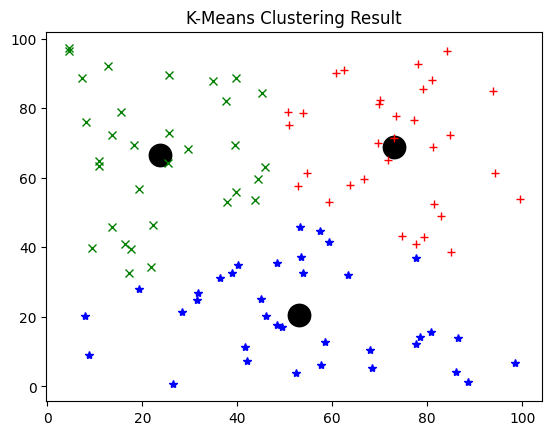

In [ ]:


import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Generate random dataset (100 points, 2 features)
data = 100 * np.random.rand(100, 2)

# Apply K-Means
model = KMeans(n_clusters=3, init='random', n_init=10, random_state=42)
model.fit(data)

# Get cluster centers and labels
centers = model.cluster_centers_
labels = model.labels_

print("Cluster Centers:\n", centers)
print("\nCluster Labels:\n", labels)

# Plot clusters
colors = ["r", "g", "b"]
markers = ["+", "x", "*"]

for i in range(len(data)):
    plt.plot(
        data[i][0],
        data[i][1],
        color=colors[labels[i]],
        marker=markers[labels[i]]
    )

# Plot cluster centers
plt.scatter(
    centers[:, 0],
    centers[:, 1],
    marker="o",
    s=200,
    linewidths=3,
    color="black"
)

plt.title("K-Means Clustering Result")
plt.show()

Sample Data:
 [[71.30935515 77.34706315]
 [57.88759205 71.36618477]
 [64.59879123 86.10231103]
 [42.262269   22.68459308]
 [20.29634673 82.37180469]
 [95.71299513 15.64842483]
 [85.47743347 60.53606313]
 [75.13399271 35.90814625]
 [10.33831586  0.3520333 ]
 [68.4618009  95.10455568]]

Total Time Taken: 0.015284538269042969 seconds

Cluster Centers:
 [[21.86098585 18.52873718]
 [72.06090895 40.88751621]
 [22.0952539  75.47144887]
 [70.60598007 11.27369152]
 [71.74058841 75.94160996]]

Labels:
 [4 4 4 0 2 3 4 1 0 4 0 3 4 4 4 0 4 1 2 2 2 0 4 2 2 2 3 0 2 3 0 1 2 1 2 1 1
 1 4 2 2 3 4 0 4 4 2 0 2 3 4 2 2 1 0 1 2 0 4 0 3 2 2 0 0 4 4 1 2 0 0 3 0 0
 0 4 0 1 4 3 2 3 1 0 3 0 0 2 4 3 1 0 0 2 0 2 4 3 2 1]


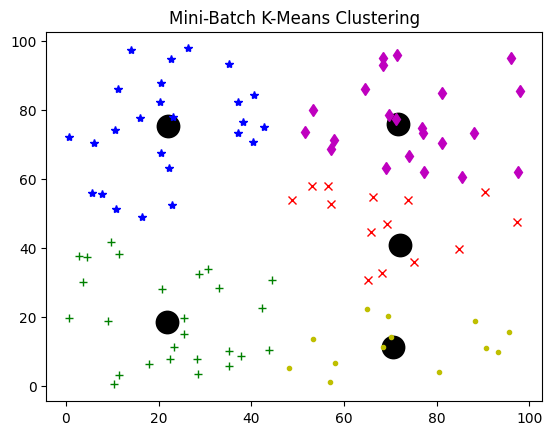

In [ ]:

import time
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import MiniBatchKMeans

# Generate random dataset (100 points, 2 features)
data = 100 * np.random.rand(100, 2)

print("Sample Data:\n", data[:10])

# Create Mini-Batch K-Means model
model = MiniBatchKMeans(
    n_clusters=5,
    init='random',
    batch_size=20,
    n_init=1,
    random_state=42
)

# Measure training time
start_time = time.time()
model.fit(data)
end_time = time.time()

print("\nTotal Time Taken:", end_time - start_time, "seconds")

# Get centers and labels
centers = model.cluster_centers_
labels = model.labels_

print("\nCluster Centers:\n", centers)
print("\nLabels:\n", labels)

# Plot clusters
colors = ["g", "r", "b", "y", "m"]
markers = ["+", "x", "*", ".", "d"]

for i in range(len(data)):
    plt.plot(
        data[i][0],
        data[i][1],
        color=colors[labels[i]],
        marker=markers[labels[i]]
    )

# Plot centroids
plt.scatter(
    centers[:, 0],
    centers[:, 1],
    marker="o",
    s=200,
    linewidths=3,
    color="black"
)

plt.title("Mini-Batch K-Means Clustering")
plt.show()

Cluster Labels: [1 1 0 1 1 0 0 1 0 0]


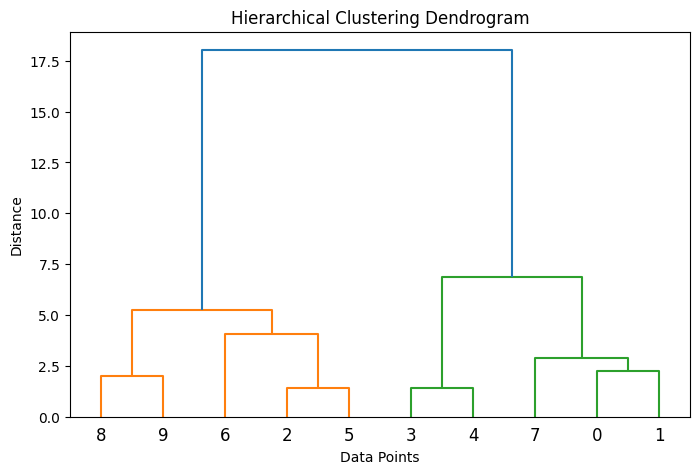

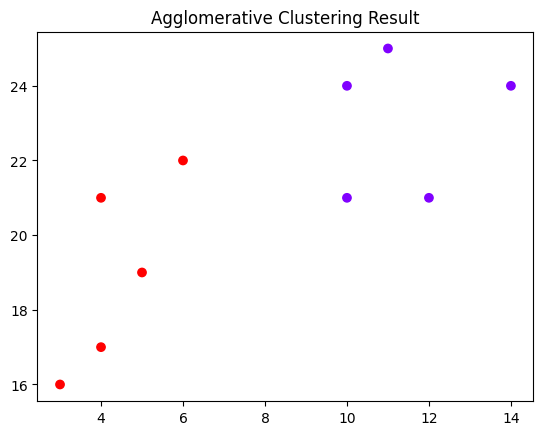


Name: Alisha Khatri
Roll No: 03


In [ ]:


import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster import hierarchy

# Sample data points
x = [4, 5, 10, 4, 3, 11, 14, 6, 10, 12]
y = [21, 19, 24, 17, 16, 25, 24, 22, 21, 21]

# Combine x and y into dataset
data = list(zip(x, y))

# Apply Agglomerative Clustering
model = AgglomerativeClustering(
    n_clusters=2,
    metric='euclidean',
    linkage='single'
)

labels = model.fit_predict(data)

print("Cluster Labels:", labels)

# Create linkage matrix for dendrogram
linkage_matrix = hierarchy.linkage(data, method='ward')

# Plot dendrogram
plt.figure(figsize=(8, 5))
hierarchy.dendrogram(linkage_matrix)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Distance")

plt.show()

# Optional: Scatter plot of clusters
plt.scatter(x, y, c=labels, cmap='rainbow')
plt.title("Agglomerative Clustering Result")
plt.show()

print("\nName: Alisha Khatri")
print("Roll No: 03")